# Prática: Uso de GPU no PyTorch

**Disciplina:** Projeto de Deep Learning

**Curso:** Ciência de Dados e IA

**Professor(a):** Renan Santos Mendes

**Email:** renansantosmendes@gmail.com

---

Este notebook apresenta uma prática guiada sobre o uso de GPU no PyTorch, com base nos
conceitos apresentados em aula: verificação do ambiente, o objeto `torch.device`, a regra
do mesmo device, execução assíncrona e o ganho de desempenho da GPU em relação à CPU.

Nesta prática não será feito o treinamento de nenhum modelo. O foco é comparar o tempo de
execução de operações tensoriais em CPU e em GPU.

## 1. Instalação e Importações

Caso esteja executando este notebook no Google Colab e seja necessário instalar algum
pacote adicional, utilize o `uv` como gerenciador de pacotes, conforme o exemplo abaixo.

In [1]:
# !pip install uv --quiet
# !uv pip install --system torch --quiet

A célula abaixo importa as bibliotecas utilizadas ao longo da prática.

In [2]:
import time

import torch
import matplotlib.pyplot as plt

## 2. Verificando o Ambiente de GPU

A função a seguir reúne as principais informações sobre a disponibilidade e as
características da GPU visível ao PyTorch, conforme apresentado em aula.

In [3]:
torch.cuda.is_available()

True

In [4]:
def check_gpu_environment() -> None:
    """Print information about the GPU environment visible to PyTorch.

    Returns:
        None
    """
    is_available = torch.cuda.is_available()
    print(f"GPU available: {is_available}")

    if is_available:
        device_count = torch.cuda.device_count()
        current_device = torch.cuda.current_device()
        device_name = torch.cuda.get_device_name(current_device)
        print(f"Number of GPUs: {device_count}")
        print(f"Current device index: {current_device}")
        print(f"Device name: {device_name}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"cuDNN version: {torch.backends.cudnn.version()}")
    else:
        print("No CUDA-capable GPU was found. The practice will run on CPU only.")

In [5]:
check_gpu_environment()

GPU available: True
Number of GPUs: 1
Current device index: 0
Device name: NVIDIA RTX 2000 Ada Generation
CUDA version: 13.0
cuDNN version: 92000


## 3. O Objeto `torch.device`

O `torch.device` é a abstração usada pelo PyTorch para indicar onde um tensor ou modelo
deve residir e ser processado. A função abaixo escolhe automaticamente a GPU quando ela
está disponível e retorna a CPU como alternativa.

In [6]:
def get_default_device() -> torch.device:
    """Return the CUDA device when available, otherwise the CPU device.

    Returns:
        torch.device: The device to be used for tensor operations.
    """
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
device = get_default_device()
print(f"Selected device: {device}")

Selected device: cuda


## 4. Movendo Tensores entre CPU e GPU

Nesta seção criamos um tensor na CPU e o movemos para o device selecionado, reforçando a
regra apresentada em aula: um tensor criado com `torch.rand` nasce na CPU por padrão e
precisa ser movido explicitamente com `.to(device)`.

In [8]:
def move_tensor_to_device(
    tensor: torch.Tensor,
    target_device: torch.device,
) -> torch.Tensor:
    """Move a tensor to the given device and print its location before and after.

    Args:
        tensor: The tensor to be moved.
        target_device: The device where the tensor should be moved to.

    Returns:
        torch.Tensor: The tensor located on the target device.
    """
    print(f"Original device: {tensor.device}")
    moved_tensor = tensor.to(target_device)
    print(f"New device: {moved_tensor.device}")
    return moved_tensor

In [10]:
sample_tensor = torch.randn(3, 3)

In [13]:
sample_tensor.device

device(type='cpu')

In [11]:
sample_tensor

tensor([[ 0.8284,  0.2535,  0.2908],
        [-0.0362, -1.2940, -0.0573],
        [-0.0685,  0.6095,  1.2560]])

In [12]:
device

device(type='cuda')

In [14]:
sample_tensor = move_tensor_to_device(sample_tensor, device)

Original device: cpu
New device: cuda:0


In [15]:
sample_tensor.device

device(type='cuda', index=0)

## 5. A Regra do Mesmo Device

A célula abaixo reproduz, de forma controlada, o erro `RuntimeError` que ocorre quando
dois tensores envolvidos na mesma operação estão em devices diferentes.

In [16]:
def demonstrate_device_mismatch_error() -> None:
    """Trigger and catch the RuntimeError caused by tensors on different devices.

    Returns:
        None
    """
    tensor_on_cpu = torch.rand(3, 3)
    tensor_on_target_device = torch.rand(3, 3).to(device)

    try:
        tensor_on_cpu + tensor_on_target_device
    except RuntimeError as error:
        print(f"RuntimeError captured as expected: {error}")

In [17]:
demonstrate_device_mismatch_error()

RuntimeError captured as expected: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


## 6. Comparando o Desempenho: CPU vs GPU

Nesta seção comparamos o tempo necessário para realizar multiplicações de matrizes de
diferentes tamanhos na CPU e na GPU, sem treinar nenhum modelo. A multiplicação de
matrizes é a operação central em redes neurais, sendo um bom indicador do ganho de
desempenho discutido em aula.

Antes de medir o tempo na GPU é necessário chamar `torch.cuda.synchronize()`, já que a
execução na GPU é assíncrona, como visto em aula.

In [18]:
def measure_matrix_multiplication_time(
    matrix_size: int,
    target_device: torch.device,
) -> float:
    """Measure the time to multiply two square matrices on the given device.

    Args:
        matrix_size: The number of rows and columns of the square matrices.
        target_device: The device where the operation will be executed.

    Returns:
        float: The elapsed time in seconds.
    """
    first_matrix = torch.rand(matrix_size, matrix_size, device=target_device)
    second_matrix = torch.rand(matrix_size, matrix_size, device=target_device)

    if target_device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()
    first_matrix @ second_matrix

    if target_device.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.perf_counter()
    return end_time - start_time

A função a seguir executa o benchmark para uma lista de tamanhos de matriz, comparando o
tempo de execução na CPU com o tempo de execução no device selecionado (GPU, quando
disponível).

In [19]:
def run_benchmark(matrix_sizes: list[int]) -> dict[str, list[float]]:
    """Run the matrix multiplication benchmark on CPU and on the selected device.

    Args:
        matrix_sizes: A list with the matrix sizes to be tested.

    Returns:
        dict[str, list[float]]: A dictionary with the elapsed times for each device.
    """
    cpu_device = torch.device("cpu")
    results = {"cpu": [], "gpu": []}

    for matrix_size in matrix_sizes:
        cpu_time = measure_matrix_multiplication_time(matrix_size, cpu_device)
        gpu_time = measure_matrix_multiplication_time(matrix_size, device)
        results["cpu"].append(cpu_time)
        results["gpu"].append(gpu_time)
        print(
            f"Matrix size {matrix_size}x{matrix_size} -> "
            f"CPU: {cpu_time:.6f}s | {device.type.upper()}: {gpu_time:.6f}s"
        )

    return results

In [22]:
8192*3

24576

In [23]:
matrix_sizes = [128, 256, 512, 1024, 2048, 4096, 8192, 24576]
benchmark_results = run_benchmark(matrix_sizes)

Matrix size 128x128 -> CPU: 0.000202s | CUDA: 0.000147s
Matrix size 256x256 -> CPU: 0.000096s | CUDA: 0.000194s
Matrix size 512x512 -> CPU: 0.000427s | CUDA: 0.004820s
Matrix size 1024x1024 -> CPU: 0.002477s | CUDA: 0.033354s
Matrix size 2048x2048 -> CPU: 0.035794s | CUDA: 0.038917s
Matrix size 4096x4096 -> CPU: 0.103801s | CUDA: 0.188535s
Matrix size 8192x8192 -> CPU: 0.871240s | CUDA: 0.403324s
Matrix size 24576x24576 -> CPU: 22.063261s | CUDA: 5.632087s


## 7. Visualizando os Resultados

O gráfico abaixo apresenta o tempo de execução em função do tamanho da matriz, permitindo
observar como a diferença entre CPU e GPU aumenta à medida que o volume de computação
cresce, assim como discutido em aula.

In [24]:
def plot_benchmark_results(
    matrix_sizes: list[int],
    results: dict[str, list[float]],
) -> None:
    """Plot the CPU and GPU execution times for each matrix size.

    Args:
        matrix_sizes: A list with the matrix sizes used in the benchmark.
        results: A dictionary with the elapsed times for each device.

    Returns:
        None
    """
    plt.figure(figsize=(8, 5))
    plt.plot(matrix_sizes, results["cpu"], marker="o", label="CPU")
    plt.plot(matrix_sizes, results["gpu"], marker="o", label=device.type.upper())
    plt.xlabel("Matrix size")
    plt.ylabel("Time (seconds)")
    plt.title("Matrix multiplication time: CPU vs GPU")
    plt.legend()
    plt.grid(True)
    plt.show()

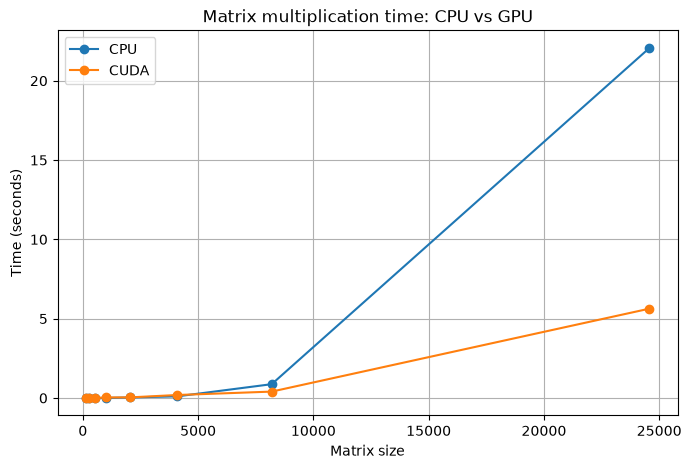

In [25]:
plot_benchmark_results(matrix_sizes, benchmark_results)

## 8. Calculando o Ganho de Desempenho

A função abaixo calcula quantas vezes a GPU foi mais rápida que a CPU para cada tamanho de
matriz testado.

In [26]:
def compute_speedup(results: dict[str, list[float]]) -> list[float]:
    """Compute how many times the GPU was faster than the CPU for each matrix size.

    Args:
        results: A dictionary with the elapsed times for each device.

    Returns:
        list[float]: A list with the speedup values.
    """
    speedup_values = []
    for cpu_time, gpu_time in zip(results["cpu"], results["gpu"]):
        speedup_values.append(cpu_time / gpu_time)
    return speedup_values

In [ ]:
speedup_values = compute_speedup(benchmark_results)

for matrix_size, speedup in zip(matrix_sizes, speedup_values):
    print(f"Matrix size {matrix_size}x{matrix_size} -> Speedup: {speedup:.2f}x")

Matrix size 128x128 -> Speedup: 1.38x
Matrix size 256x256 -> Speedup: 0.49x
Matrix size 512x512 -> Speedup: 0.09x
Matrix size 1024x1024 -> Speedup: 0.07x
Matrix size 2048x2048 -> Speedup: 0.92x
Matrix size 4096x4096 -> Speedup: 0.55x
Matrix size 8192x8192 -> Speedup: 2.16x
Matrix size 24576x24576 -> Speedup: 3.92x


: 